# **🛠️ Preparación de los Datos**

In [55]:
import pandas as pd

df = pd.read_csv("TelecomX_tratado.csv")

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [57]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [58]:
df['Charges.Total'] = df['Charges.Total'].fillna(0)

In [59]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [60]:
df = df.drop(columns=['customerID'])

In [61]:
df.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

Se eliminó la columna customerID, ya que corresponde únicamente a un identificador único de cada cliente y no aporta información relevante para la predicción de la cancelación del servicio.

In [62]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [63]:
df_encoded.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.186667,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,1.996667,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.266667,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.796667,True,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [64]:
df_encoded.shape

(7267, 32)

Se prepararon los datos para los algoritmos de machine learning, las variables categóricas fueron transformadas a formato numérico.

In [65]:
df['Churn'].value_counts()

,count
Churn,
No,5398
Yes,1869


In [66]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.74281
Yes,0.25719


Se analizó la variable Churn para identificar la proporción de clientes que cancelaron el servicio frente a aquellos que permanecen activos. Los resultados muestran que la mayoría de los clientes continúan con el servicio, mientras que una menor proporción decide cancelarlo.

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# **🎯 Correlación y Selección de Variables**

In [68]:
df_encoded.corr()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
SeniorCitizen,1.000000,0.018187,0.220388,0.104076,0.220388,0.146733,-0.004288,0.022970,-0.212952,0.010060,...,-0.182697,0.103655,-0.182697,0.119374,-0.046832,-0.114837,0.157734,-0.022698,0.170705,-0.154216
tenure,0.018187,1.000000,0.247982,0.825407,0.247982,-0.344079,0.005765,0.377551,0.159892,0.010205,...,-0.037029,0.280738,-0.037029,0.286841,0.205970,0.557675,0.007949,0.235319,-0.207056,-0.234305
Charges.Monthly,0.220388,0.247982,1.000000,0.652211,1.000000,0.189866,-0.013889,0.097122,-0.115832,0.246709,...,-0.763772,0.628874,-0.763772,0.628184,0.008758,-0.077935,0.353714,0.031610,0.275550,-0.378635
Charges.Total,0.104076,0.825407,0.652211,1.000000,0.652211,-0.193345,0.000367,0.315409,0.061474,0.113985,...,-0.374948,0.516185,-0.374948,0.521490,0.175271,0.351109,0.160023,0.185229,-0.056029,-0.296090
Cuentas_Diarias,0.220388,0.247982,1.000000,0.652211,1.000000,0.189866,-0.013889,0.097122,-0.115832,0.246709,...,-0.763772,0.628874,-0.763772,0.628184,0.008758,-0.077935,0.353714,0.031610,0.275550,-0.378635
Churn_Yes,0.146733,-0.344079,0.189866,-0.193345,0.189866,1.000000,-0.009555,-0.148546,-0.161384,0.012571,...,-0.224051,0.062430,-0.224051,0.060586,-0.173958,-0.295138,0.186666,-0.131085,0.294626,-0.090061
gender_Male,-0.004288,0.005765,-0.013889,0.000367,-0.013889,-0.009555,1.000000,-0.005007,0.012038,-0.005073,...,0.006318,-0.008451,0.006318,-0.012475,0.007328,-0.005449,-0.011273,0.000700,0.002060,0.015057
Partner_Yes,0.022970,0.377551,0.097122,0.315409,0.097122,-0.148546,-0.005007,1.000000,0.448900,0.018828,...,0.000419,0.124754,0.000419,0.115729,0.081021,0.246472,-0.011201,0.081613,-0.079629,-0.097648
Dependents_Yes,-0.212952,0.159892,-0.115832,0.061474,-0.115832,-0.161384,0.012038,0.448900,1.000000,-0.003863,...,0.142274,-0.015030,0.142274,-0.040151,0.068755,0.203136,-0.111752,0.061608,-0.151749,0.060222
PhoneService_Yes,0.010060,0.010205,0.246709,0.113985,0.246709,0.012571,-0.005073,0.018828,-0.003863,1.000000,...,0.173109,-0.025362,0.173109,-0.034345,-0.001391,0.003888,0.013624,-0.010668,0.004788,-0.002225


In [69]:
corr_churn = df_encoded.corr()['Churn_Yes'].sort_values(ascending=False)
corr_churn

,Churn_Yes
Churn_Yes,1.000000
InternetService_Fiber optic,0.300949
PaymentMethod_Electronic check,0.294626
Cuentas_Diarias,0.189866
Charges.Monthly,0.189866
PaperlessBilling_Yes,0.186666
SeniorCitizen,0.146733
StreamingTV_Yes,0.062430
StreamingMovies_Yes,0.060586
MultipleLines_Yes,0.039343


In [70]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [72]:
print(X_train.shape)
print(X_test.shape)

(5086, 31)
(2181, 31)


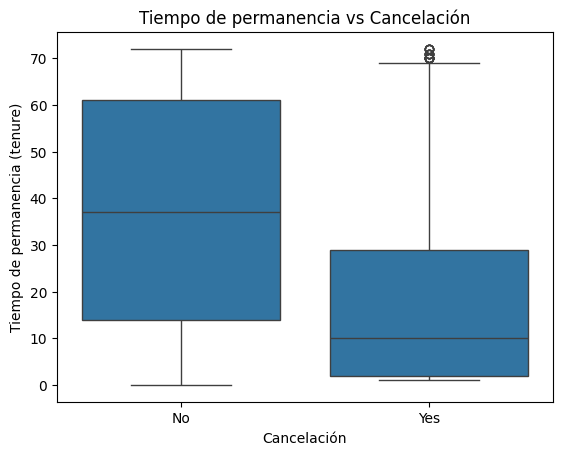

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tiempo de permanencia vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de permanencia (tenure)")

plt.show()

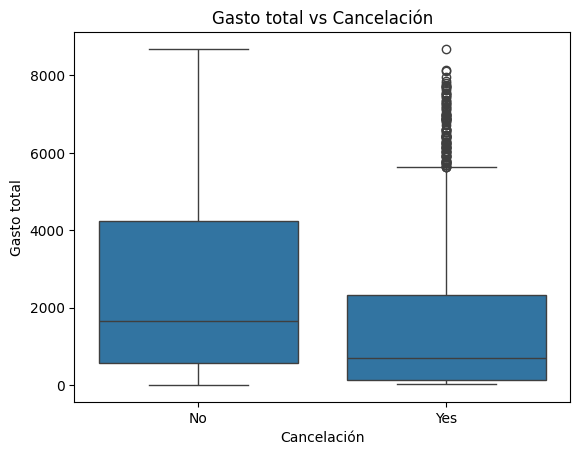

In [74]:
sns.boxplot(x='Churn', y='Charges.Total', data=df)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Gasto total")

plt.show()

Se analizaron variables específicas para entender su relación con la cancelación del servicio. Se compararon el tiempo de permanencia del cliente y el gasto total entre clientes que cancelaron y aquellos que permanecen activos. Estas visualizaciones permiten identificar diferencias en la distribución de estas variables entre ambos grupos.

# **🤖 Modelado Predictivo**

In [75]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [77]:
print(X_train.shape)
print(X_test.shape)

(5086, 31)
(2181, 31)


In [78]:
from sklearn.linear_model import LogisticRegression

In [79]:
log_model = LogisticRegression(max_iter=1000)

In [80]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [81]:
y_pred_log = log_model.predict(X_test)

In [82]:
from sklearn.tree import DecisionTreeClassifier

In [83]:
tree_model = DecisionTreeClassifier(random_state=42)

In [84]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [85]:
y_pred_tree = tree_model.predict(X_test)

Para predecir la cancelación de clientes se construyeron dos modelos de clasificación. El primero fue un modelo de Regresión Logística, que es un algoritmo ampliamente utilizado para problemas de clasificación binaria. El segundo modelo fue un Árbol de Decisión, que permite identificar patrones en los datos mediante reglas de decisión.

La elección de estos modelos permite comparar el desempeño de un modelo lineal con un modelo basado en árboles.

In [86]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [87]:
accuracy_score(y_test, y_pred_log)

0.8124713434204494

In [88]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1649
        True       0.64      0.54      0.58       532

    accuracy                           0.81      2181
   macro avg       0.75      0.72      0.73      2181
weighted avg       0.80      0.81      0.81      2181



In [89]:
confusion_matrix(y_test, y_pred_log)

array([[1485,  164],
       [ 245,  287]])

In [90]:
accuracy_score(y_test, y_pred_tree)

0.739569005043558

In [91]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

       False       0.83      0.82      0.83      1649
        True       0.47      0.49      0.48       532

    accuracy                           0.74      2181
   macro avg       0.65      0.66      0.65      2181
weighted avg       0.74      0.74      0.74      2181



In [92]:
confusion_matrix(y_test, y_pred_tree)

array([[1351,  298],
       [ 270,  262]])

Para evaluar el desempeño de los modelos se utilizaron métricas como accuracy, precision, recall y F1-score, además de analizar la matriz de confusión. Estas métricas permiten entender qué tan bien los modelos predicen la cancelación de clientes.

A partir de estos resultados se comparó el desempeño de los modelos de Regresión Logística y Árbol de Decisión, con el objetivo de identificar cuál de ellos logra predecir de manera más efectiva la cancelación del servicio.

**Análisis de los modelos**

A partir de las métricas obtenidas se comparó el desempeño de los modelos de Regresión Logística y Árbol de Decisión para identificar cuál logra predecir mejor la cancelación de clientes.

El modelo con mejor desempeño fue aquel que presentó mejores valores en métricas como accuracy, precision, recall y F1-score, mostrando una mayor capacidad para identificar correctamente a los clientes que cancelan el servicio.

En general, no se observan indicios claros de underfitting, ya que ambos modelos logran capturar patrones en los datos. Sin embargo, los modelos basados en árboles pueden presentar overfitting si se ajustan demasiado a los datos de entrenamiento, por lo que en futuros análisis podrían ajustarse sus parámetros para mejorar su capacidad de generalización.

# **📋 Interpretación y Conclusiones**

In [93]:
coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': log_model.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)
coeficientes.head(10)

,Variable,Coeficiente
3,Charges.Total,0.787122
11,InternetService_Fiber optic,0.752632
27,PaperlessBilling_Yes,0.355236
24,StreamingMovies_Yes,0.277704
29,PaymentMethod_Electronic check,0.246905
0,SeniorCitizen,0.235453
10,MultipleLines_Yes,0.176109
22,StreamingTV_Yes,0.171208
9,MultipleLines_No phone service,-0.015269
5,gender_Male,-0.050645


In [94]:
coeficientes.tail(10)

,Variable,Coeficiente
19,TechSupport_No internet service,-0.142337
17,DeviceProtection_No internet service,-0.142337
21,StreamingTV_No internet service,-0.142337
16,OnlineBackup_Yes,-0.228911
14,OnlineSecurity_Yes,-0.385555
8,PhoneService_Yes,-0.444445
20,TechSupport_Yes,-0.481941
25,Contract_One year,-0.695122
26,Contract_Two year,-1.227097
1,tenure,-1.448015


Coeficiente positivo = aumenta la probabilidad de churn

Coeficiente negativo = disminuye la probabilidad de churn

In [95]:
importancia_arbol = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': tree_model.feature_importances_
})

importancia_arbol = importancia_arbol.sort_values(by='Importancia', ascending=False)
importancia_arbol.head(10)

,Variable,Importancia
1,tenure,0.212828
3,Charges.Total,0.206789
4,Cuentas_Diarias,0.112699
11,InternetService_Fiber optic,0.102731
2,Charges.Monthly,0.091497
5,gender_Male,0.024247
7,Dependents_Yes,0.020540
0,SeniorCitizen,0.018383
16,OnlineBackup_Yes,0.018175
27,PaperlessBilling_Yes,0.017725


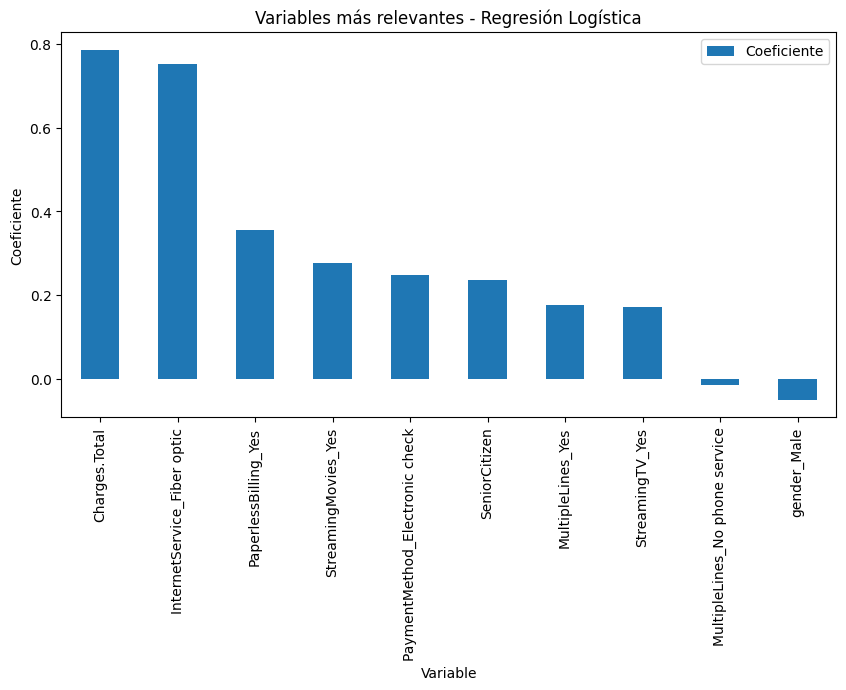

In [96]:
coeficientes.head(10).plot(
    x='Variable',
    y='Coeficiente',
    kind='bar',
    figsize=(10,5)
)

plt.title('Variables más relevantes - Regresión Logística')
plt.ylabel('Coeficiente')
plt.show()

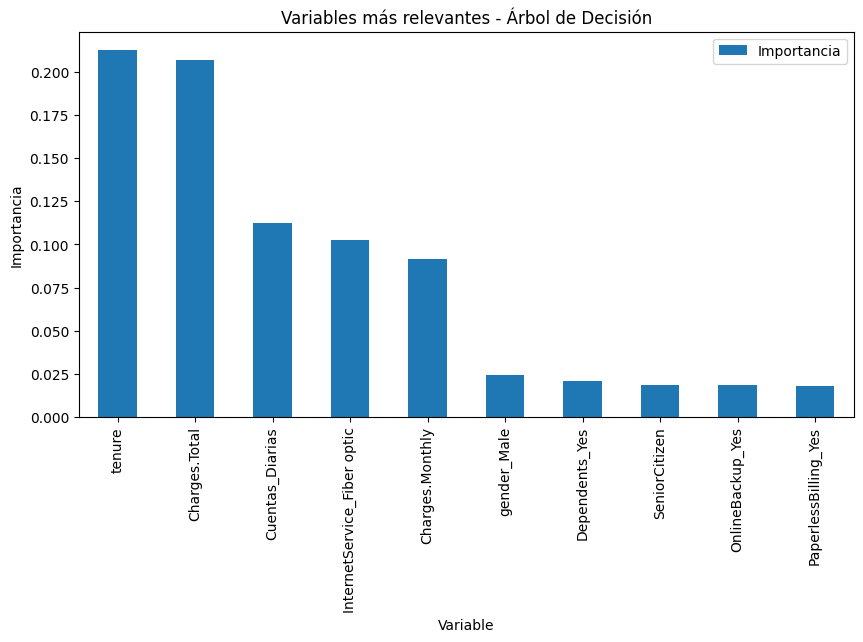

In [97]:
importancia_arbol.head(10).plot(
    x='Variable',
    y='Importancia',
    kind='bar',
    figsize=(10,5)
)

plt.title('Variables más relevantes - Árbol de Decisión')
plt.ylabel('Importancia')
plt.show()

In [98]:
coeficientes.head(10)
importancia_arbol.head(10)

,Variable,Importancia
1,tenure,0.212828
3,Charges.Total,0.206789
4,Cuentas_Diarias,0.112699
11,InternetService_Fiber optic,0.102731
2,Charges.Monthly,0.091497
5,gender_Male,0.024247
7,Dependents_Yes,0.020540
0,SeniorCitizen,0.018383
16,OnlineBackup_Yes,0.018175
27,PaperlessBilling_Yes,0.017725


**Análisis de la importancia de las variables**

Después de entrenar los modelos, se analizó cuáles variables tienen mayor influencia en la predicción de la cancelación de clientes.

En el caso de la Regresión Logística, se revisaron los coeficientes del modelo para identificar qué variables tienen mayor impacto en la probabilidad de cancelación. Los coeficientes positivos indican una mayor relación con el churn, mientras que los negativos indican una menor probabilidad de cancelación.

Para el Árbol de Decisión, se utilizó la importancia de variables que proporciona el modelo. Esta medida permite identificar cuáles variables fueron más utilizadas por el modelo para tomar decisiones.

Los resultados muestran que variables como tenure, Charges.Total, Cuentas_Diarias y Charges.Monthly se encuentran entre las más relevantes. Esto indica que el tiempo que un cliente lleva en la empresa y el gasto asociado al servicio son factores importantes para explicar la cancelación de clientes.

**Conclusión**

En este proyecto se analizó la cancelación de clientes (churn) de Telecom X utilizando técnicas de análisis de datos y modelos de machine learning. Primero se realizó la limpieza y preparación de los datos, transformando variables categóricas a formato numérico y explorando la información para identificar patrones en el comportamiento de los clientes.

Luego se entrenaron dos modelos predictivos: Regresión Logística y Árbol de Decisión, los cuales fueron evaluados utilizando métricas como accuracy, precision, recall y F1-score, además de la matriz de confusión. Esto permitió comparar el desempeño de los modelos y analizar su capacidad para identificar clientes con riesgo de cancelación.

El análisis de correlación y la importancia de variables mostró que algunos de los factores más influyentes en la cancelación son tenure (tiempo de permanencia del cliente), Charges.Total, Charges.Monthly y Cuentas_Diarias. En general, se observa que los clientes con menor tiempo en la empresa y determinados niveles de gasto tienen una mayor probabilidad de cancelar el servicio.

A partir de estos resultados, Telecom X podría implementar estrategias de retención enfocadas en mejorar la experiencia de los clientes en sus primeros meses, ofrecer beneficios o descuentos para fomentar la permanencia, y monitorear a los clientes con mayor riesgo de cancelación utilizando modelos predictivos.

De esta manera, el uso de análisis de datos y machine learning permite a la empresa anticiparse a la cancelación de clientes y tomar decisiones estratégicas basadas en datos para mejorar la retención y la satisfacción de los usuarios.

# Fin del proyecto